# Análisis ANOVA - Morfometría de Callisaurus draconoides
Análisis de Varianza (ANOVA) para responder a las preguntas de investigación basadas en los datos morfométricos obtenidos de libro en 1922.

A continuación se cargaron los datos con los que se trabajará, además anexo información referente a los significados de abreviaciones:

> Todas las medidas están en mm

| Abreviación | Significado |
|-------------|-------------|
| Largo HC | Largo hocico-cloaca |
| Largo C | Largo de cloaca-cola |
| HI | Hocico a posterior de interparietal |
| HO | Hocico a oído |
| AC | Ancho de cabeza |
| EP | Extremidad posterior |
| EA | Extremidad anterior |
| BQaCD | Base del quinto a cuarto dedo pata trasera |
| PF | Poros femorales |

> ⚠️ **Nota:** Un individuo de C.d.ventralis fue identificado como posible cría/juvenil.

In [ ]:
#install.packages("readr")
df <- read.csv("../data/processed/morfometricos.csv", na.strings = "NA")
df

fuente,subespecie,individuo,Largo_HC,Largo_C,HI,HO,AC,EA,EP,BQaCD,PF
<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<chr>
Libro_1922,C. d. crinitus,NA,77,93,13.0,15.0,12,37,62,25.0,19 a 20
Libro_1922,C. d. draconoides,NA,55,62,11.0,12.0,10,29,50,22.0,12 a 20
Libro_1922,C. d. draconoides,NA,60,73,11.0,13.0,11,31,52,22.0,NA
Libro_1922,C. d. draconoides,NA,65,NA,13.0,14.0,12,33,61,28.0,NA
Libro_1922,C. d. draconoides,NA,67,80,12.0,14.0,11,36,62,27.0,NA
Libro_1922,C. d. draconoides,NA,67,NA,13.0,14.0,11,35,62,27.0,NA
Libro_1922,C. d. draconoides,NA,68,NA,12.0,14.0,12,37,65,28.0,NA
Libro_1922,C. d. draconoides,NA,80,122,15.0,17.0,14,40,68,27.0,12 a 19
Libro_1922,C. d. carmenensis,NA,75,110,13.0,15.0,13,42,72,29.0,NA


Se trabajará de manera paralela con dos análisis: El primero correspondiente a la literatura del libro de 1922, utilizando todas las medidas morfométricas disponibles. El segundo enfocándose únicamente en las variables con información común, combinando los datos de la literatura de 1922 con las muestras recolectadas en 2019 en Sonora.



In [19]:
# DATASETS PARA TRABAJO

# ANÁLISIS LITERATURA


df_1922 <- subset(df, fuente == "Libro_1922")

#Para este análisis se elimina la subespecie que solo tiene un individuo : C. d. crinitus
df_1922 <- subset(df_1922, subespecie != "C. d. crinitus")

cat("\n--- CONTEO PARA ANÁLISIS 1 (Por Subespecie en 1922) ---\n")
print(table(df_1922$subespecie))

# ANÁLISIS GEOGRÁFICO (Libro 1922 - 2019)
columnas <- c("fuente", "individuo", "Largo_HC", "Largo_C")
df_geo <- df[, columnas]
df_geo <- subset(df_geo, !is.na(Largo_HC))


cat("\n--- CONTEO PARA ANÁLISIS 2 (Por Fuente/Ubicación) ---\n")
print(table(df_geo$fuente))

#df_1922
#df_geo


--- CONTEO PARA ANÁLISIS 1 (Por Subespecie en 1922) ---

C. d. carmenensis C. d. draconoides  C. d. inusitatus       C. d. myrus 
                6                 7                 6                 6 
 C. d. splendidus   C. d. ventralis 
                6                 7 



--- CONTEO PARA ANÁLISIS 2 (Por Fuente/Ubicación) ---

Cerro_Bachoco_2019 Cerro_Johnson_2019         Libro_1922 Playa_Miramar_2019 
                33                 11                 39                  8 


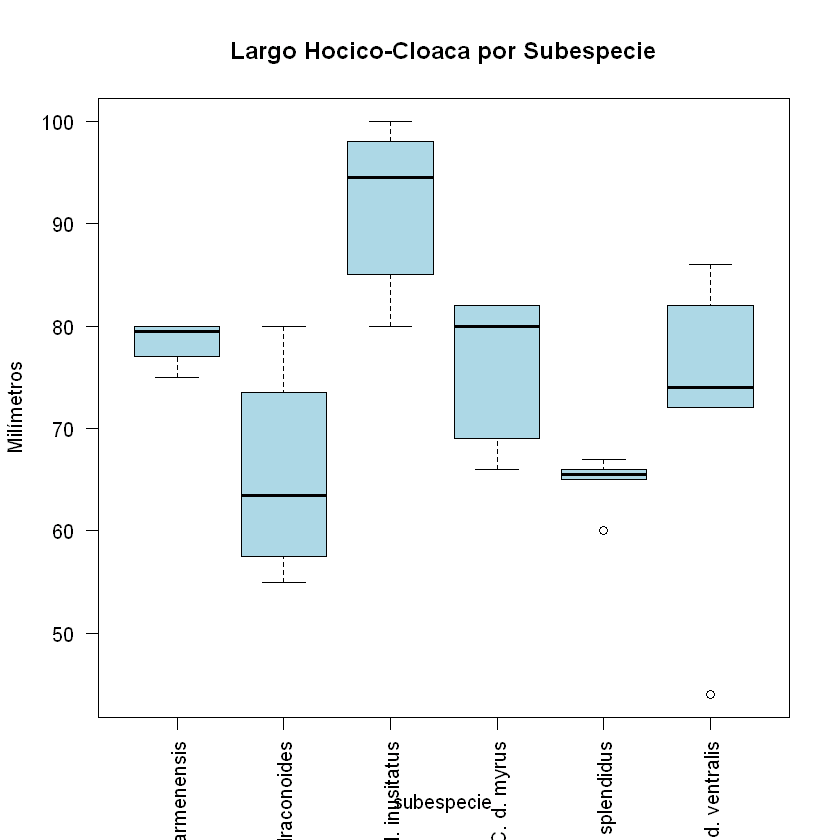

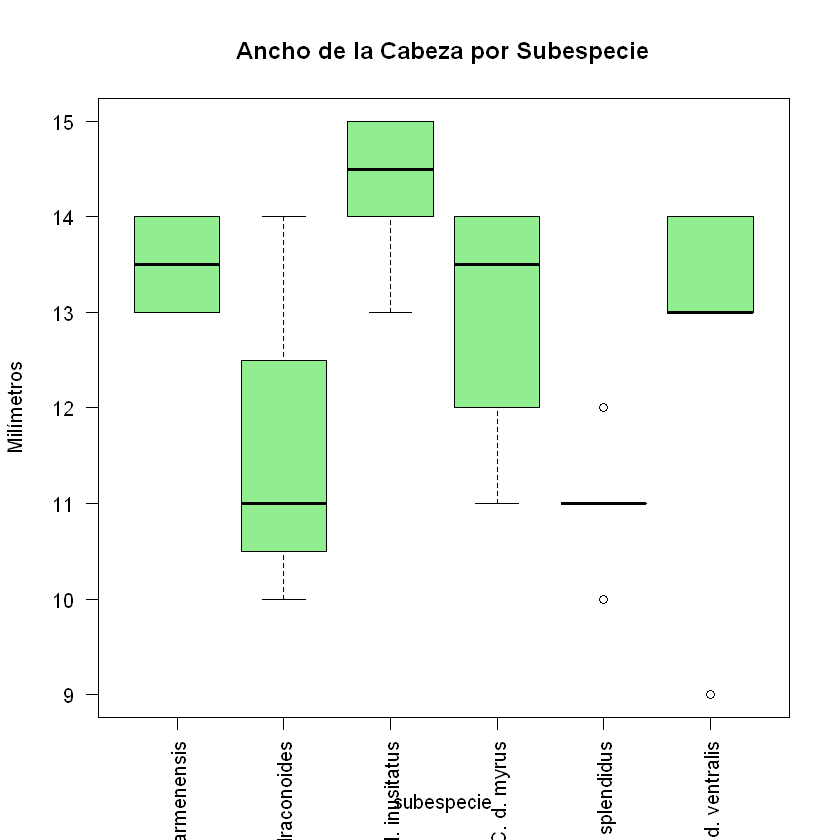

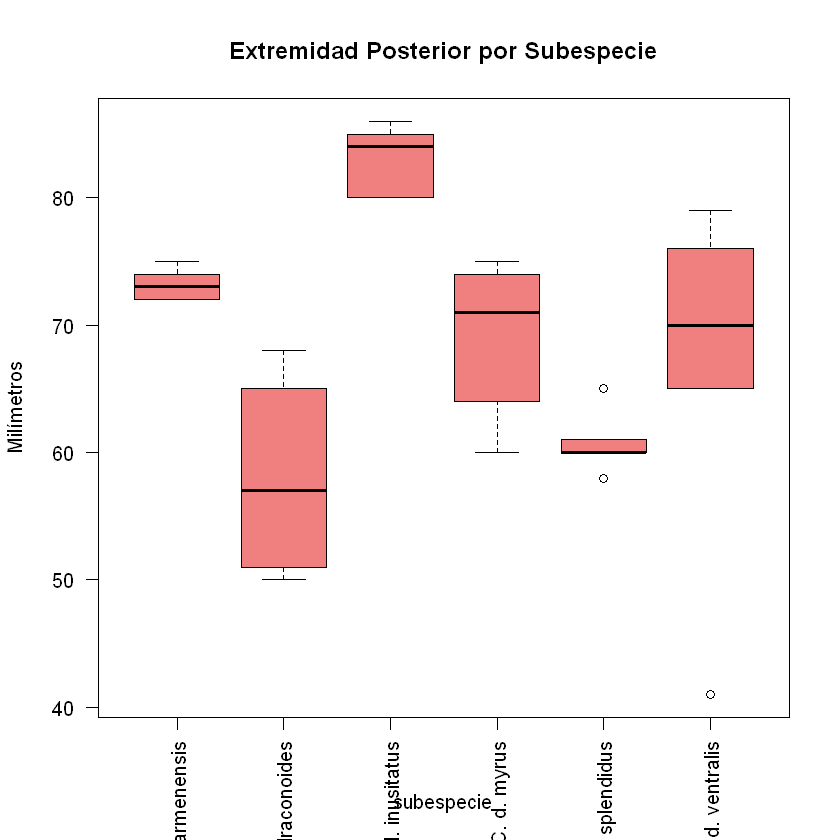

In [29]:
# Gráfico 1: Tamaño del Cuerpo (Hocico-Cloaca)
boxplot(Largo_HC ~ subespecie, data = df_1922,
        main = "Largo Hocico-Cloaca por Subespecie",
        ylab = "Milímetros", 
        col = "lightblue", 
        las = 2)

# Gráfico 2: Ancho de la Cabeza
boxplot(AC ~ subespecie, data = df_1922,
        main = "Ancho de la Cabeza por Subespecie",
        ylab = "Milímetros", 
        col = "lightgreen", 
        las = 2)

# Gráfico 3: Tamaño de Pata Trasera (Extremidad Posterior)
boxplot(EP ~ subespecie, data = df_1922,
        main = "Extremidad Posterior por Subespecie",
        ylab = "Milímetros", 
        col = "lightcoral", 
        las = 2)


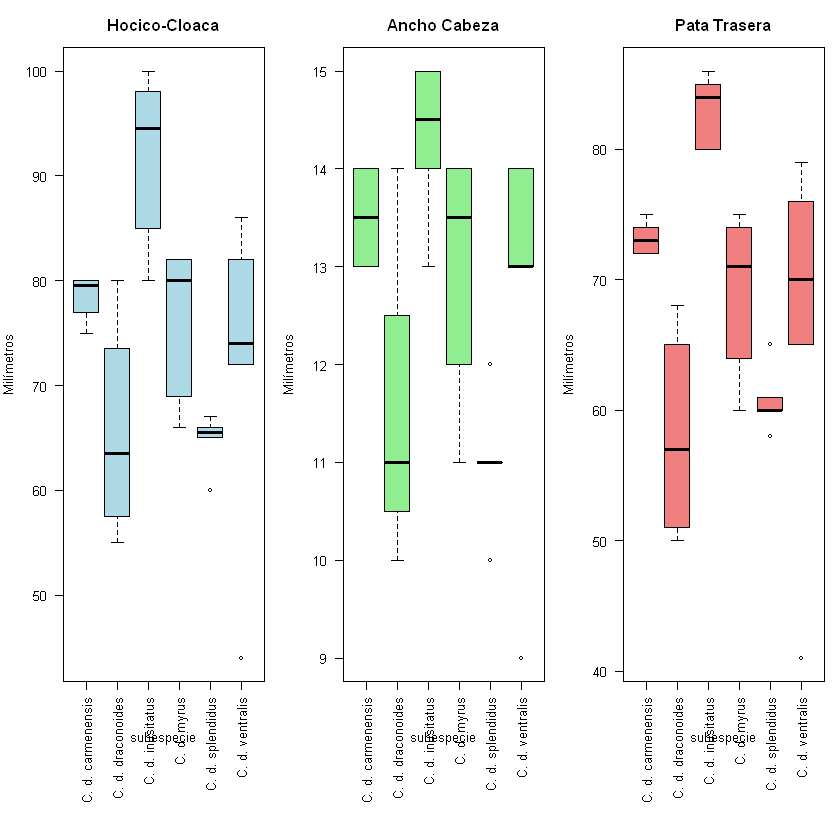

In [31]:
# Plot en una sola imágen
par(mfrow = c(1, 3), mar = c(10, 4, 3, 1))

# Gráfico 1
boxplot(Largo_HC ~ subespecie, data = df_1922,
        main = "Hocico-Cloaca", ylab = "Milímetros", col = "lightblue", las = 2)

# Gráfico 2
boxplot(AC ~ subespecie, data = df_1922,
        main = "Ancho Cabeza", ylab = "Milímetros", col = "lightgreen", las = 2)

# Gráfico 3
boxplot(EP ~ subespecie, data = df_1922,
        main = "Pata Trasera", ylab = "Milímetros", col = "lightcoral", las = 2)

# Restaurar la configuración gráfica a la normalidad para no afectar siguientes gráficos
par(mfrow = c(1, 1), mar = c(5, 4, 4, 2) + 0.1)


# ANOVA

Para este primer acercamiento se plantea la siguientes hipótesis:
### H0: No existen diferencias estadísticamente significativas en las medidas morfométricas (principipalmente el Largo Hocico - Cloaca) entre las diferentes subespecies históricas de Callisaurus draconoides. Es decir, todas miden lo mismo.

### H1: Al menos una de las subespecies presenta diferencias morfométricas estadísticamente significaticas respecto a las demás, lo que valida la existencia de variación fenotípica entre ellas.

            Df Sum Sq Mean Sq F value   Pr(>F)    
subespecie   5   2846   569.2   7.271 0.000224 ***
Residuals   26   2035    78.3                     
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


	Shapiro-Wilk normality test

data:  residuals(modelo_hc)
W = 0.91261, p-value = 0.01317



	Bartlett test of homogeneity of variances

data:  Largo_HC by subespecie
Bartlett's K-squared = 21.328, df = 5, p-value = 0.0007023



	Kruskal-Wallis rank sum test

data:  Largo_HC by subespecie
Kruskal-Wallis chi-squared = 18.775, df = 5, p-value = 0.002117


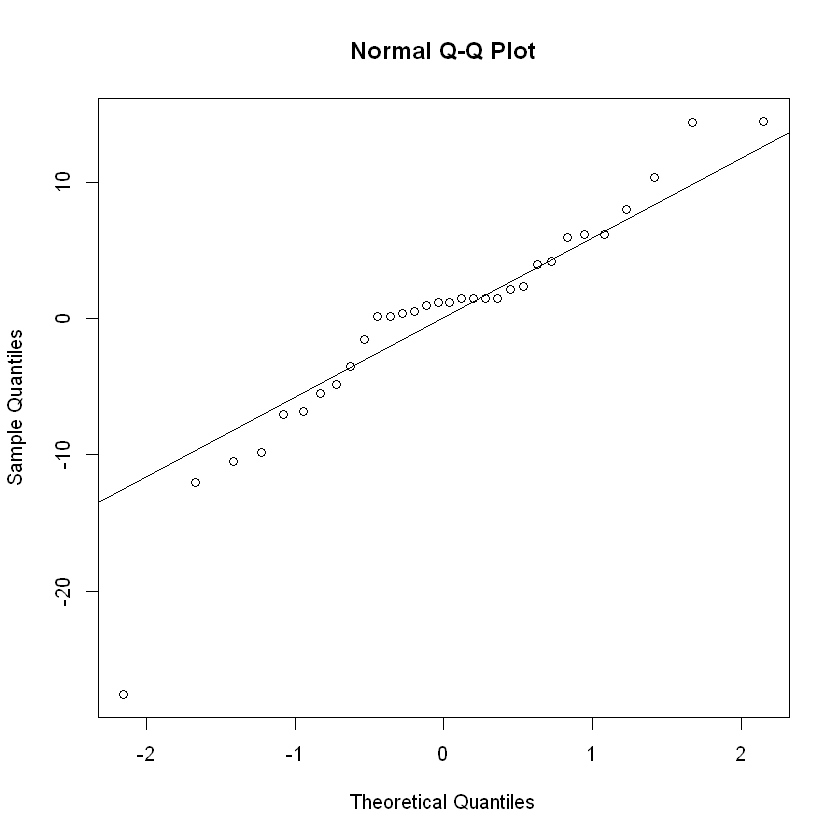

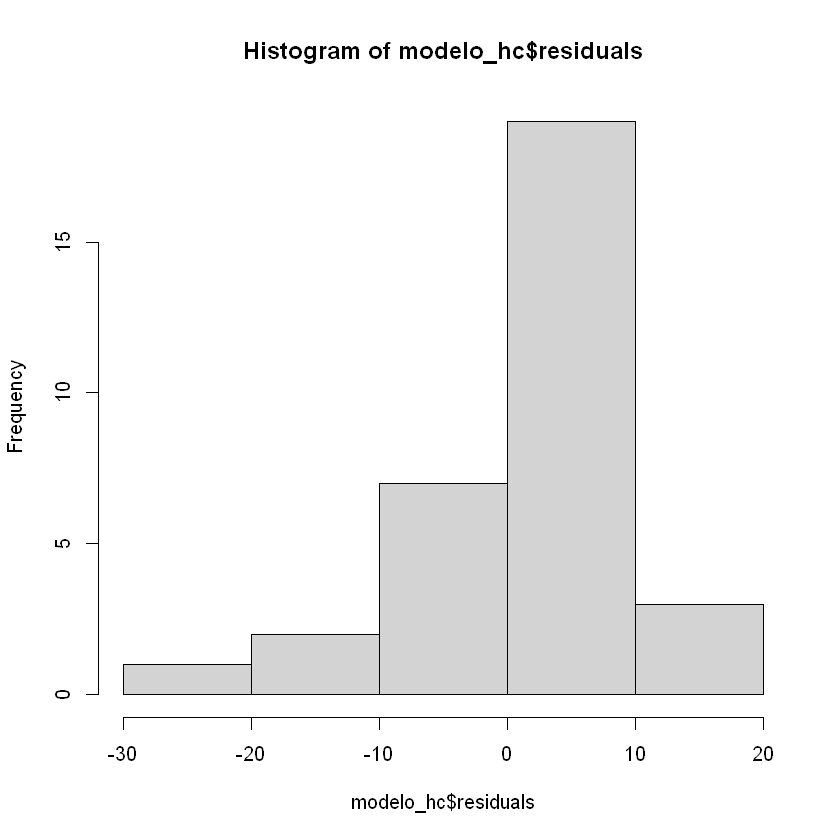

In [47]:
# ANOVA PARA LAS DIFERENTES MEDIDAS 

#Largo_HC

modelo_hc <- aov(Largo_HC ~ subespecie, data = df_1922)
summary(modelo_hc)

shapiro.test(residuals(modelo_hc))
bartlett.test(Largo_HC ~ subespecie, data = df_1922)
kruskal.test(Largo_HC ~ subespecie, data = df_1922)

qqnorm(modelo_hc$residuals)
qqline(modelo_hc$residuals)

hist(modelo_hc$residuals)

            Df Sum Sq Mean Sq F value  Pr(>F)   
subespecie   5  43.20   8.639   5.583 0.00127 **
Residuals   26  40.23   1.547                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


	Shapiro-Wilk normality test

data:  residuals(modelo_ac)
W = 0.94841, p-value = 0.1299



	Bartlett test of homogeneity of variances

data:  AC by subespecie
Bartlett's K-squared = 11.435, df = 5, p-value = 0.0434



	Kruskal-Wallis rank sum test

data:  AC by subespecie
Kruskal-Wallis chi-squared = 16.058, df = 5, p-value = 0.006679


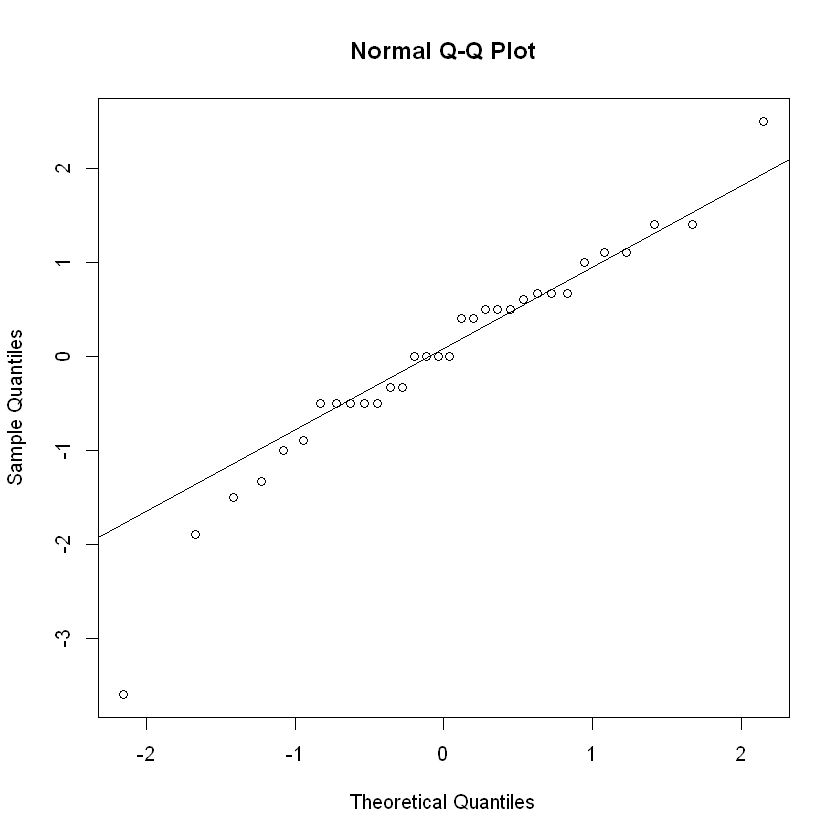

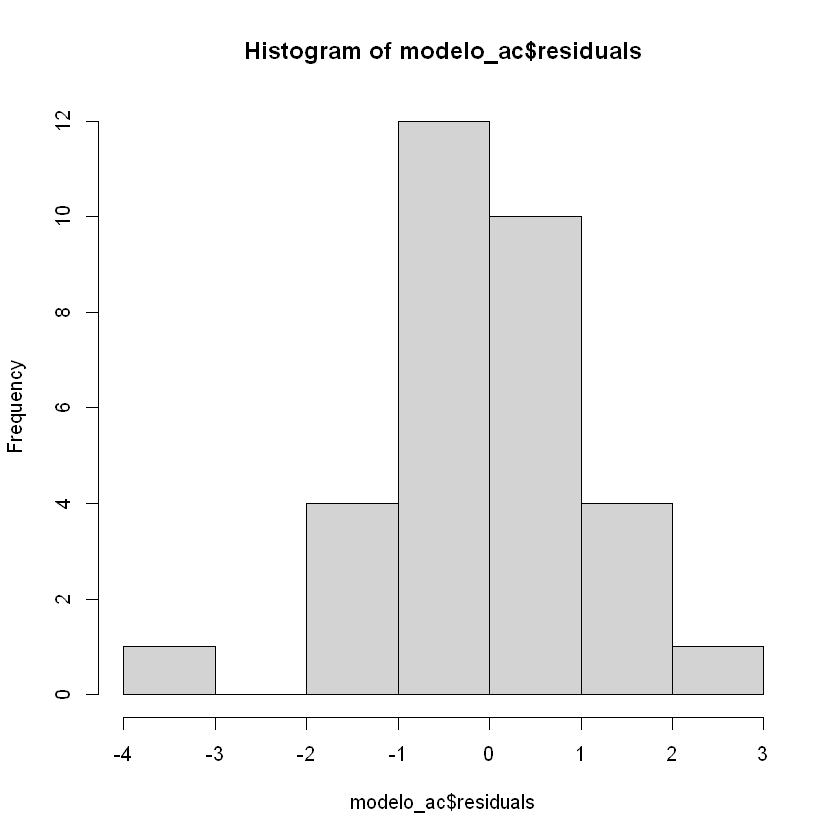

In [46]:
# ANOVA PARA LAS DIFERENTES MEDIDAS 

# AC

modelo_ac <- aov(AC ~ subespecie, data = df_1922)
summary(modelo_ac)

shapiro.test(residuals(modelo_ac))
bartlett.test(AC ~ subespecie, data = df_1922)
kruskal.test(AC ~ subespecie, data = df_1922)

qqnorm(modelo_ac$residuals)
qqline(modelo_ac$residuals)

hist(modelo_ac$residuals)

            Df Sum Sq Mean Sq F value   Pr(>F)    
subespecie   5   2248   449.7   8.568 6.74e-05 ***
Residuals   26   1365    52.5                     
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


	Shapiro-Wilk normality test

data:  residuals(modelo_ep)
W = 0.8709, p-value = 0.001218



	Bartlett test of homogeneity of variances

data:  EP by subespecie
Bartlett's K-squared = 31.061, df = 5, p-value = 9.111e-06



	Kruskal-Wallis rank sum test

data:  EP by subespecie
Kruskal-Wallis chi-squared = 21.817, df = 5, p-value = 0.0005672


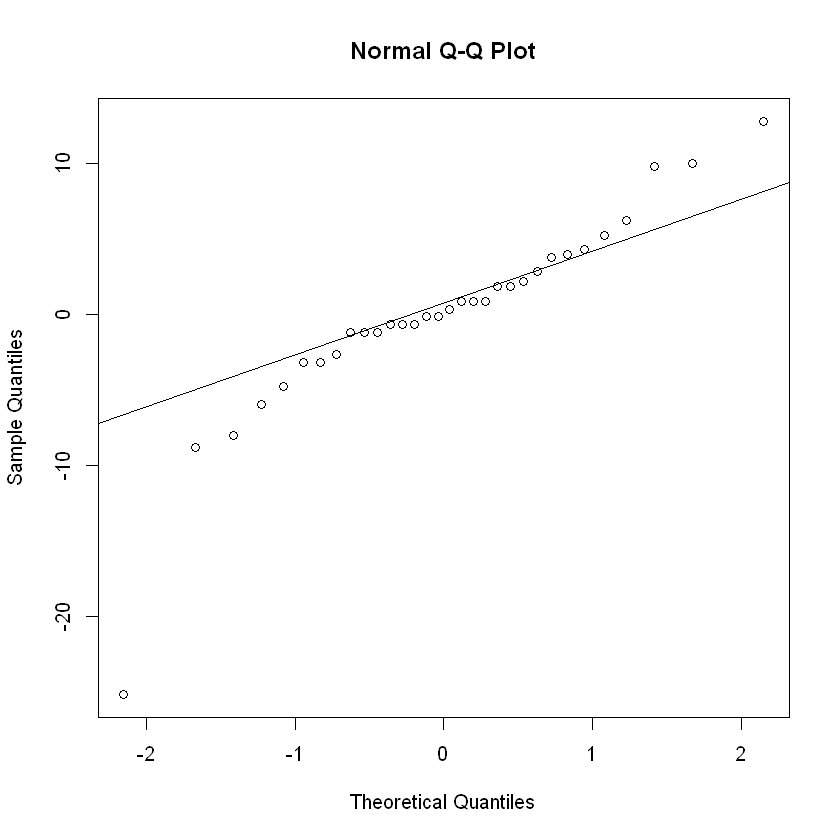

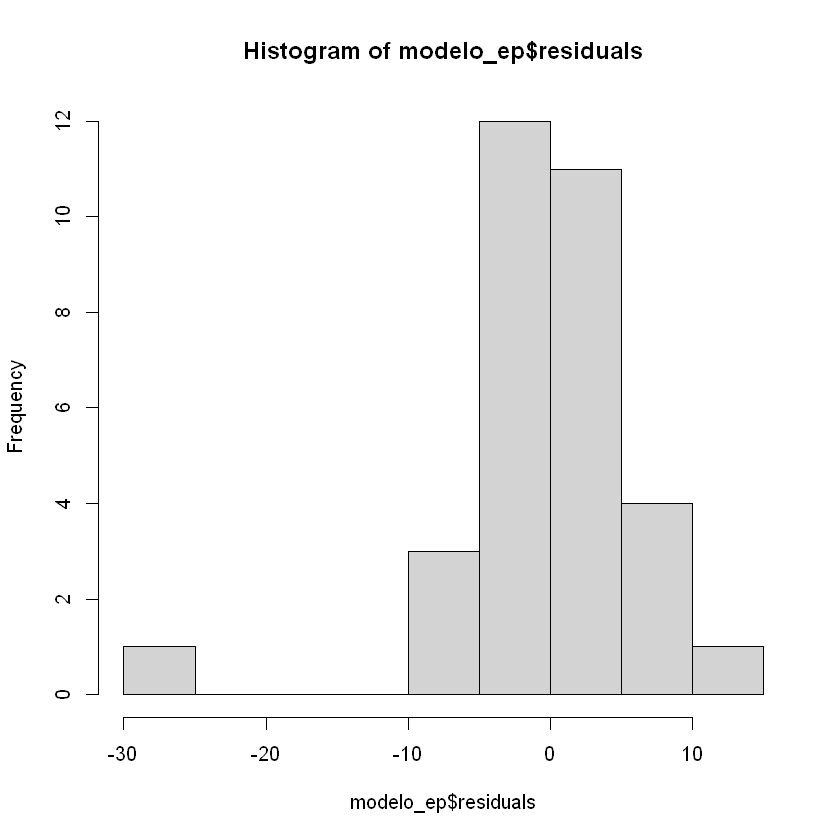

In [45]:
# ANOVA PARA LAS DIFERENTES MEDIDAS 

# EP - Extremidad Posterior 

modelo_ep <- aov(EP ~ subespecie, data = df_1922)
summary(modelo_ep)

shapiro.test(residuals(modelo_ep))
bartlett.test(EP ~ subespecie, data = df_1922)
kruskal.test(EP ~ subespecie, data = df_1922)

qqnorm(modelo_ep$residuals)
qqline(modelo_ep$residuals)

hist(modelo_ep$residuals)

### Resumen de Resultados Estadísticos (Poblaciones 1922)

Para evaluar las diferencias morfométricas entre las subespecies históricas de *Callisaurus draconoides*, el análisis se centró en tres variables representativas: Largo Hociclo-Cloaca (Largo_HC), Ancho de la Cabeza (AC) y Extremidad Posterior (EP). 

A continuación se resumen los resultados obtenidos del ANOVA, se incluye un análisis con supuestos paramétricos con la prueba de Normalidad (Shapiro) y de Homocedasticidad (Bartlett), también mediante una prueba no paramétrica (Kruskal-Wallis).

| Variable Anatómica | Prueba de Normalidad <br>(Shapiro-Wilk) | Prueba de Varianzas <br>(Bartlett) | Prueba No Paramétrica <br>(Kruskal-Wallis) | Conclusión H0 |
| :--- | :--- | :--- | :--- | :--- |
| **Largo_HC** (Hocico-Cloaca) | W = 0.912, *p = 0.013* | K² = 21.32, *p < 0.001* | χ² = 18.77, ***p = 0.002*** | **Se rechaza** |
| **AC** (Ancho de Cabeza) | W = 0.948, *p = 0.129* (Normal) | K² = 11.43, *p = 0.043* | χ² = 16.05, ***p = 0.006*** | **Se rechaza** |
| **EP** (Extremidad Posterior) | W = 0.870, *p = 0.001* | K² = 31.06, *p < 0.001* | χ² = 21.81, ***p < 0.001*** | **Se rechaza** |

> **Nota:** Para que el uso de ANOVA sea válido, la variable debe cumplir **ambos** supuestos (Normalidad y Homocedasticidad). Aunque la medida `AC` presenta una distribución normal, incumple el supuesto de varianzas homogéneas (*p < 0.05* en Bartlett). Por ende, el uso de Kruskal-Wallis es el método más robusto y estadísticamente correcto para las tres variables.

**Conclusión:** 
Se rechaza la Hipótesis Nula (H0) en todos los casos. Los resultados indican de manera contundente que existen diferencias significativas en el tamaño general, proporciones craneales y estructura locomotora entre los grupos evaluados. Esto valida estadísticamente la separación fenotípica de las subespecies documentadas en la literatura de 1922.


In [52]:
# ANÁLISIS DE COMPONENTES PRINCIPALES (PCA)

columnas_pca <- c("subespecie", "Largo_HC", "AC", "EP", "EA", "BQaCD")
df_pca <- df_1922[, columnas_pca]
df_pca <- na.omit(df_pca)

pca_resultado <- prcomp(df_pca[, -1], scale. = TRUE) #scale.=True todas las medidas tienen el mismo peso

print(summary(pca_resultado))

Importance of components:
                          PC1     PC2     PC3     PC4     PC5
Standard deviation     2.1788 0.37491 0.27769 0.14437 0.11935
Proportion of Variance 0.9495 0.02811 0.01542 0.00417 0.00285
Cumulative Proportion  0.9495 0.97756 0.99298 0.99715 1.00000


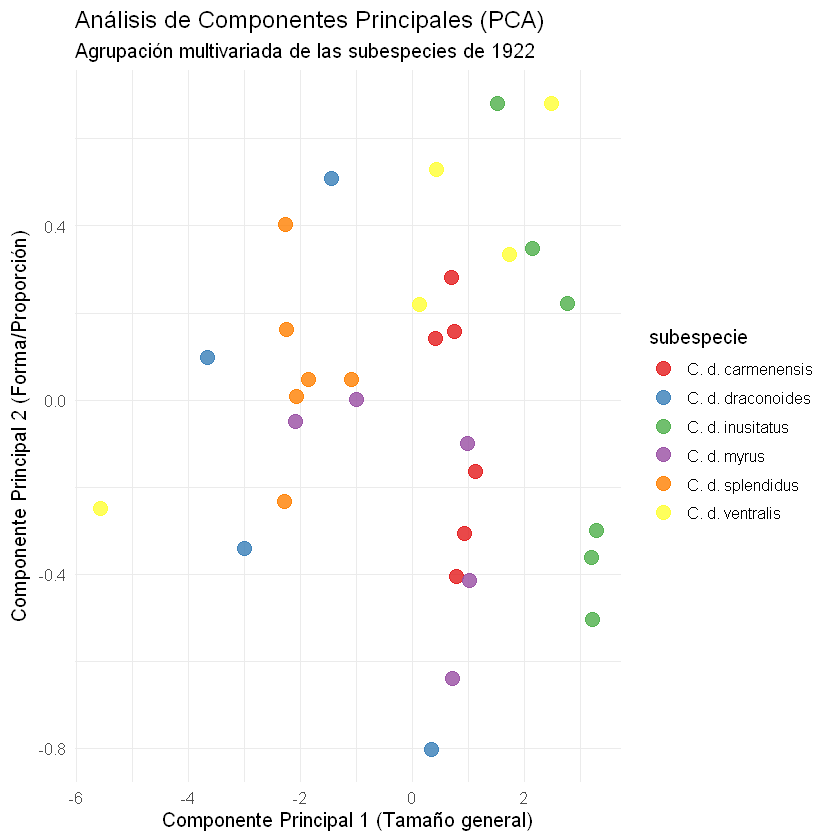

In [51]:
library(ggplot2)
df_grafico_pca <- data.frame(pca_resultado$x, subespecie = df_pca$subespecie)

ggplot(df_grafico_pca, aes(x = PC1, y = PC2, color = subespecie)) +
  geom_point(size = 4, alpha = 0.8) +
  theme_minimal() +
  scale_color_brewer(palette = "Set1") +
  labs(title = "Análisis de Componentes Principales (PCA)",
       subtitle = "Agrupación multivariada de las subespecies de 1922",
       x = "Componente Principal 1 (Tamaño general)",
       y = "Componente Principal 2 (Forma/Proporción)") +
  theme(legend.position = "right", 
        text = element_text(size = 12))

El siguiente análisis estará enfocado en los datos de muestra tomados en 2019, incluidos los del Libro de 1922. Los datos recientes contienen información del lugar donde provienen, los cuatro grupos a comparar son:
 - Libro 1922.
 - Cerro Bachoco, Hermosillo, Sonora, 2019.
 - Cerro Johnson, Hermosillo, Sonora, 2019
 - Playa Miramar, Guaymas, Sonora, 2019.

 La incógnita es si las poblaciones de 2019 tienen un tamaño diferente al que se registra el los datos en la literatura, o difieren entre los cerros y la playa. En este dataset solo se cuenta con el dato de Largo Hocico-Cloaca (Largo_HC), por lo que el análisis se llevará solamente en esta medida.

 Para el ANOVA se plantean las siguientes hipótesis:

 ### H0: No existen diferencias significativas en el tamaño coporal entre las poblaciones de 2019 y los registros del Libro de 1922.

 ### H1: Al menos una ubicación o época presenta un tamaño corporal significativamente distinto a las demás.

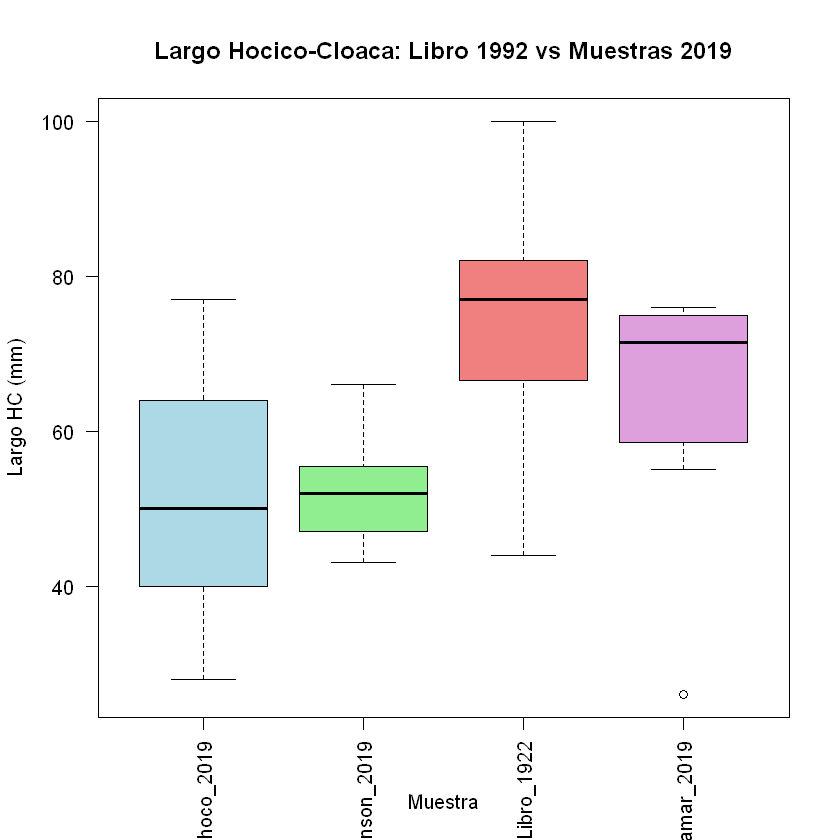

In [54]:
# Boxplot

boxplot(Largo_HC ~ fuente, data = df_geo,
        main = "Largo Hocico-Cloaca: Libro 1992 vs Muestras 2019",
        ylab = "Largo HC (mm)", 
        xlab = "Muestra",
        col = c("lightblue", "lightgreen", "lightcoral", "plum"), 
        las = 2) # las=2 gira las etiquetas para que se puedan leer


            Df Sum Sq Mean Sq F value  Pr(>F)    
fuente       3  12976    4325   24.25 1.7e-11 ***
Residuals   87  15519     178                    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


	Shapiro-Wilk normality test

data:  residuals(modelo_geo)
W = 0.98571, p-value = 0.4242



	Bartlett test of homogeneity of variances

data:  Largo_HC by fuente
Bartlett's K-squared = 6.9417, df = 3, p-value = 0.07378


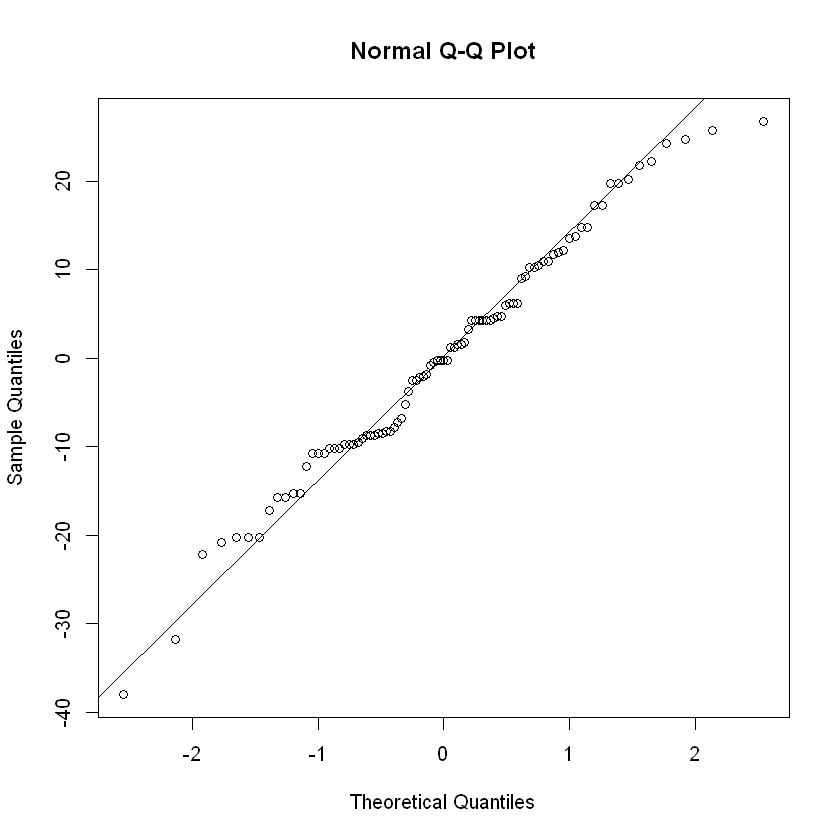

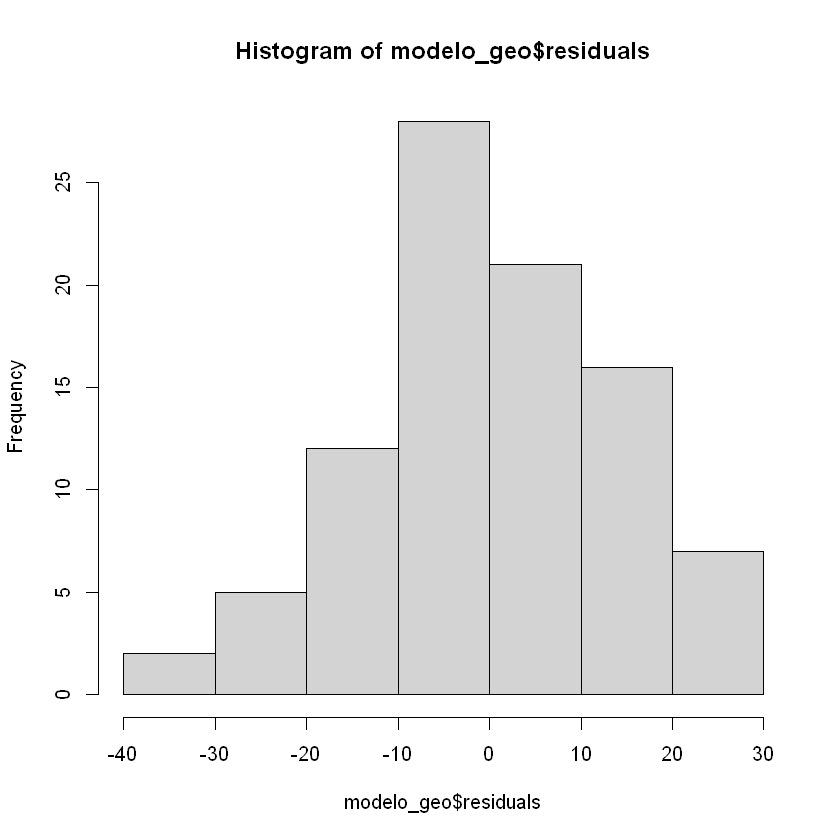

In [60]:
modelo_geo <- aov(Largo_HC ~ fuente, data = df_geo)
summary(modelo_geo)

shapiro.test(residuals(modelo_geo))
bartlett.test(Largo_HC ~ fuente, data = df_geo)

qqnorm(modelo_geo$residuals)
qqline(modelo_geo$residuals)

hist(modelo_geo$residuals)


--- DIFERENCIAS PAREADAS (Tukey's HSD) ---
  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = Largo_HC ~ fuente, data = df_geo)

$fuente
                                            diff           lwr       upr
Cerro_Johnson_2019-Cerro_Bachoco_2019   2.242424  -9.937583052 14.422432
Libro_1922-Cerro_Bachoco_2019          25.557110  17.282424036 33.831795
Playa_Miramar_2019-Cerro_Bachoco_2019  13.787879   0.001046659 27.574711
Libro_1922-Cerro_Johnson_2019          23.314685  11.371205532 35.258165
Playa_Miramar_2019-Cerro_Johnson_2019  11.545455  -4.710406828 27.801316
Playa_Miramar_2019-Libro_1922         -11.769231 -25.347554369  1.809093
                                          p adj
Cerro_Johnson_2019-Cerro_Bachoco_2019 0.9628400
Libro_1922-Cerro_Bachoco_2019         0.0000000
Playa_Miramar_2019-Cerro_Bachoco_2019 0.0499752
Libro_1922-Cerro_Johnson_2019         0.0000110
Playa_Miramar_2019-Cerro_Johnson_2019 0.2527479
Playa_Miramar_2019-

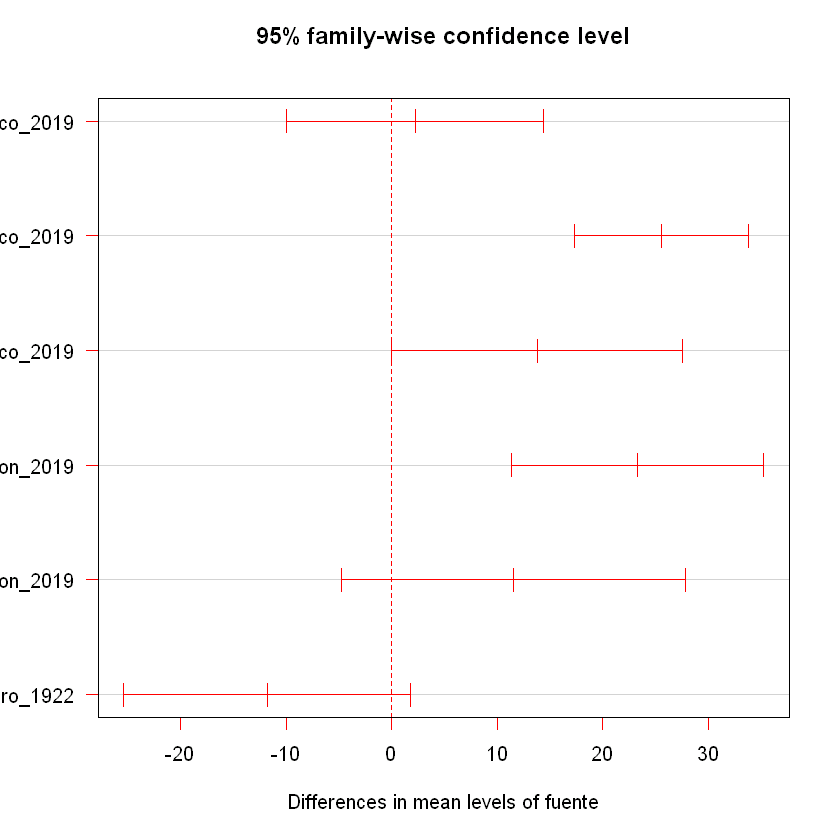

In [61]:
# PRUEBA DE TUKEY


cat("\n--- DIFERENCIAS PAREADAS (Tukey's HSD) ---\n")
prueba_tukey <- TukeyHSD(modelo_geo)
print(prueba_tukey)
# Opcional: Un gráfico rápido para visualizar las diferencias de Tukey
plot(prueba_tukey, las=1, col="red")

Para evaluar si el tamaño general (Largo Hocico-Cloaca) varía geográfica y temporalmente, se compararon los registros históricos de la literatura (1922) contra tres poblaciones modernas muestreadas en Sonora durante 2019 (Cerro Bachoco, Cerro Johnson y Playa Miramar).

A diferencia de las comparaciones entre subespecies, **la distribución de estos datos sí cumplió los supuestos paramétricos** de normalidad (Prueba de Shapiro-Wilk) y de homogeneidad de varianzas (Prueba de Bartlett). Por lo tanto, fue estadísticamente válido y riguroso utilizar un **Análisis de Varianza (ANOVA)**, obteniendo un resultado altamente significativo (p-valor < 0.001). También se realizó la **Prueba de Tukey** para identificar las diferencias entre pares.

| Comparación Geográfica / Temporal | Diferencia Promedio (mm) | Valor p ajustado (Tukey) | Conclusión de Tamaño |
| :--- | :--- | :--- | :--- |
| **Libro 1922 vs. Cerro Bachoco 2019** | 25.5 mm (1922 > Bachoco) | ***p < 0.001*** | Diferencia altamente significativa |
| **Libro 1922 vs. Cerro Johnson 2019** | 23.3 mm (1922 > Johnson) | ***p < 0.001*** | Diferencia altamente significativa |
| **Playa Miramar 2019 vs. Cerro Bachoco 2019** | 13.7 mm (Miramar > Bachoco) | ***p = 0.049*** | Diferencia significativa |
| **Playa Miramar 2019 vs. Libro 1922** | -11.7 mm | *p = 0.113* (No Sig.) | **Sin diferencias significativas** |
| **Cerro Johnson 2019 vs. Cerro Bachoco 2019** | 2.2 mm | *p = 0.962* (No Sig.) | **Sin diferencias significativas** |

**Implicación Ecológica y Evolutiva:** 
El análisis revela una fuerte divergencia morfométrica ligada a la geografía y el tiempo. Las poblaciones modernas de entornos continentales/cerros (Cerro Bachoco y Cerro Johnson en Hermosillo) presentan un tamaño corporal drásticamente menor en comparación con los registros de la literatura. 

En contraste, la población costera moderna (Playa Miramar) conserva un tamaño estadísticamente similar a la línea de la literatura. Esto sugiere dos posibles escenarios que merecen investigación profunda: 
1. Las características de los entornos de cerro (Hermosillo) favorecen a fenotipos más pequeños.
2. Los registros históricos documentados en el Libro de 1922 estuvieron fuertemente o sesgados hacia subespecies costeras e insulares (como *C. d. inusitatus* o *C. d. carmenensis*), las cuales se caracterizan naturalmente por un tamaño corporal mayor.
